# LASSO回归分析

## $\S1$ Configuration & Data Preparation

In [42]:
# Configuration
## Loading Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


## Data Path
Path = "./Raw_Data_3.xlsx"
Dependent_Variable = "USD_index_Close"

## Param Grid
param_grid = {
    "model__alpha": np.logspace(-6, -3, 100)
}

## CV Scoring
scoring = {
    ### sklearn默认maximize the score, so we use prefix "neg"
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}


In [43]:
# Data Preparation
## Loading Data
Data = pd.read_excel(Path, index_col="日期")
print("Data Size:", Data.shape)

## Data Split & Scale
### Split Features and Label
X = Data.drop(columns=[Dependent_Variable])
y = Data[[Dependent_Variable]]

Data Size: (3357, 32)


In [44]:
### Split Train, Valid and Test Sets
train_size = int(len(Data) * 0.8)
X_train, X_test = X.iloc[:train_size, :], X.iloc[train_size:, :]
y_train, y_test = y.iloc[:train_size, :], y.iloc[train_size:, :]

#### Split Train Set into Tims Series
tsCV = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(tsCV.split(X_train)):
    print(f"Fold {fold}: Train {len(train_idx)}, Valid {len(test_idx)}")


Fold 0: Train 450, Valid 447
Fold 1: Train 897, Valid 447
Fold 2: Train 1344, Valid 447
Fold 3: Train 1791, Valid 447
Fold 4: Train 2238, Valid 447


## $\S2$ Model Training & Predicting

In [45]:
## Generating Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(random_state=42)),
]
)

## Model Selection
### Grid_Search with Pipe on Grid using TimeSeriesSplit CV on Train Set
gsCV = GridSearchCV(
    estimator = pipe,
    param_grid=param_grid,
    cv = tsCV,
    scoring = scoring,
    refit = "R2",
    n_jobs = -1,
    verbose = 2
)
gsCV.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,{'model__alpha': array([1.0000...00000000e-03])}
,scoring,"{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,n_jobs,-1
,refit,'R2'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [46]:
### printing best model
#### Best Hyper Parameters:
print("Grid Search 最佳参数: ", gsCV.best_params_)
print("对应的(CV平均)最优R2:", gsCV.best_score_)

#### CV Results:
result = pd.DataFrame(gsCV.cv_results_)
cols_to_show = ["param_model__alpha", "mean_test_RMSE", "mean_test_MAE", "mean_test_R2"]
result["mean_test_MAE"] = -result["mean_test_MAE"]
result["mean_test_RMSE"] = -result["mean_test_RMSE"]
print(result[cols_to_show].sort_values(by="mean_test_R2", ascending=False).head(10))

Grid Search 最佳参数:  {'model__alpha': np.float64(0.00032745491628777284)}
对应的(CV平均)最优R2: -0.26248933522215506
    param_model__alpha  mean_test_RMSE  mean_test_MAE  mean_test_R2
83            0.000327        0.001509       0.001208     -0.262489
84            0.000351        0.001509       0.001213     -0.262492
82            0.000305        0.001510       0.001204     -0.263641
85            0.000376        0.001510       0.001218     -0.263865
81            0.000285        0.001511       0.001201     -0.265694
80            0.000266        0.001513       0.001199     -0.268456
86            0.000404        0.001513       0.001227     -0.269505
79            0.000248        0.001515       0.001198     -0.271753
78            0.000231        0.001517       0.001196     -0.275493
87            0.000433        0.001517       0.001237     -0.277430


In [47]:
## Model Prediction
### 在gsCV中，refit已经选取了最优模型，Pipe在整个训练集上进行了重新训练
best_ridge = gsCV.best_estimator_
best_ridge.named_steps["model"].alpha
y_pred = best_ridge.predict(X_test)

Text(0.5, 1.0, 'LASSO Regression Prediction')

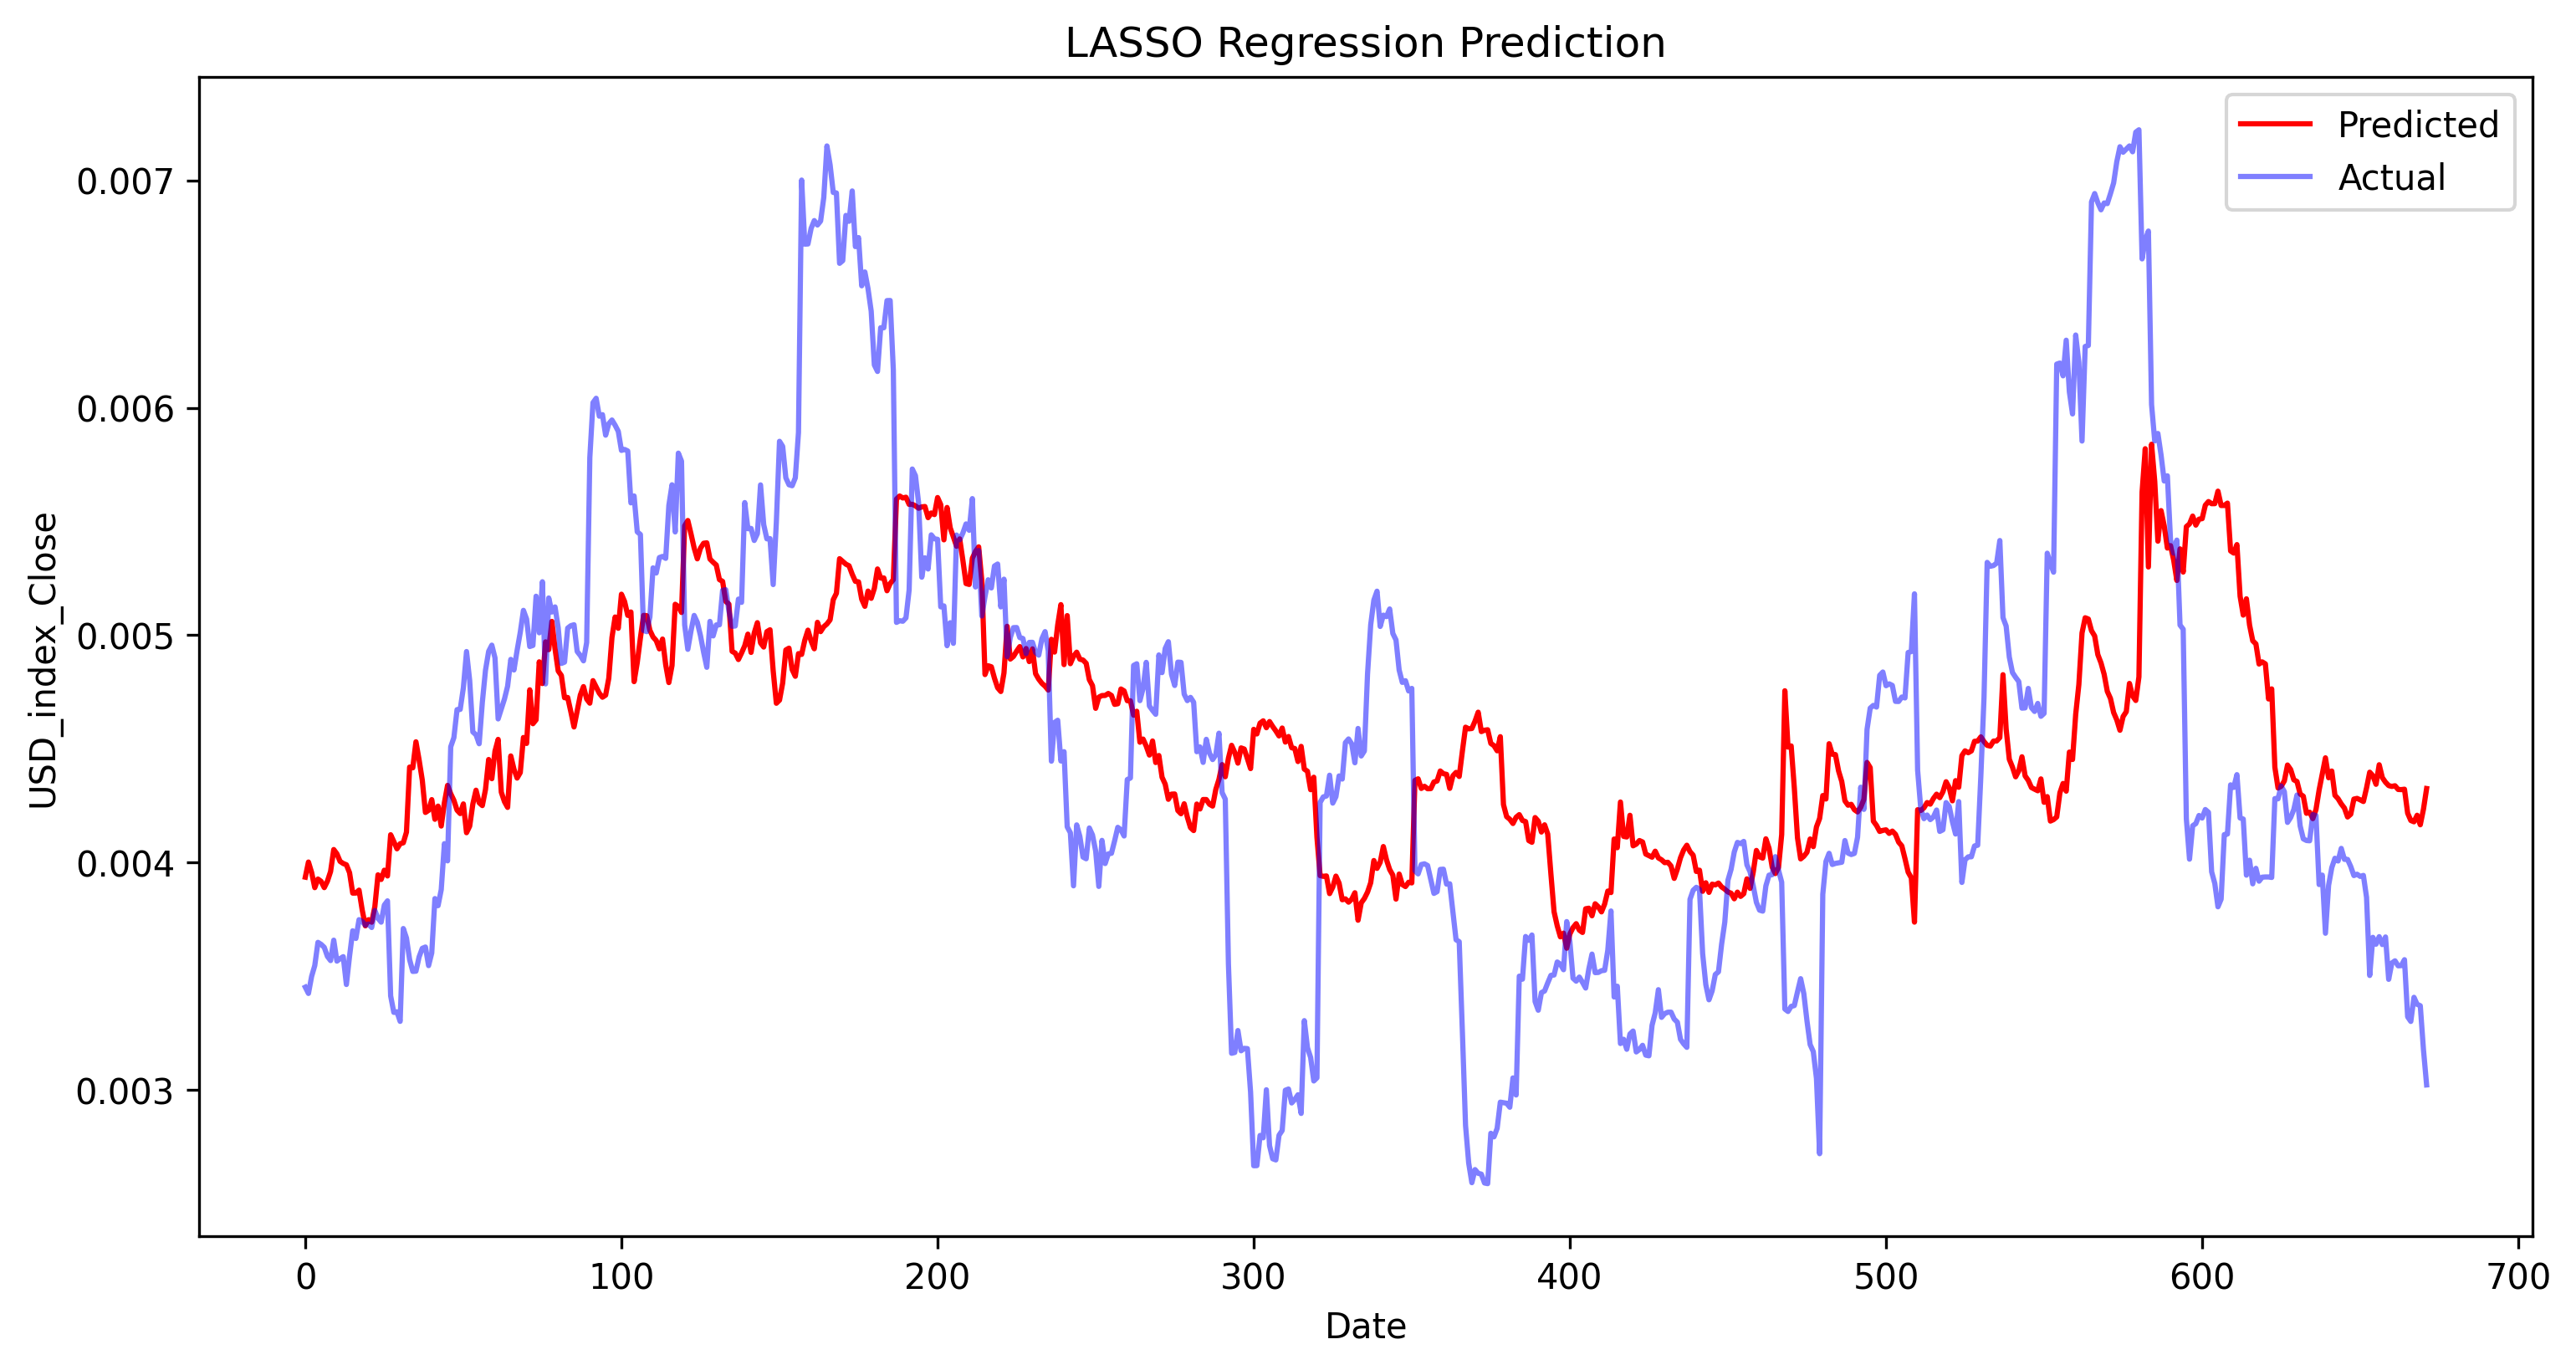

In [48]:
### Prediction Visualization
fig, ax1 = plt.subplots(figsize=(12,6), dpi=300)
ax1.plot(y_pred, label="Predicted", color="red")
ax1.plot(y_test.values, label="Actual", color="blue", alpha=0.5)
ax1.set_xlabel("Date")
ax1.set_ylabel("USD_index_Close")
ax1.legend()
ax1.set_title("LASSO Regression Prediction")

## $\S3$ Model Evaluation & Explanation

In [49]:
## Model Evaluation
# 4.2 计算测试集指标
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("=== 测试集表现 ===")
print(f"MAE  : {test_mae:.6f}")
print(f"RMSE  : {test_rmse:.6f}")
print(f"R^2  : {test_r2:.6f}")

=== 测试集表现 ===
MAE  : 0.000679
RMSE  : 0.000874
R^2  : 0.289021


In [50]:
print(X_train.columns)
best_ridge.named_steps["model"].coef_

Index(['USD_EUR_Open', 'USD_JPY_Open', 'USD_GBP_Open', 'USD_CNY_Open',
       'GOLD_Open', 'WTI_Open', 'US_10Y_Open', 'CN_10Y_Open', 'UK_10Y_Open',
       'JP_10Y_Open', 'GER_10Y_Open', 'VIX_Open', 'US_index_Open',
       'CN_index_Open', 'UK_index_Open', 'JP_index_Open', 'GER_index_Open',
       'US_10Y-CN_10Y_Open', 'US_10Y-GER_10Y_Open', 'US_10Y-UK_10Y_Open',
       'US_10Y-JP_10Y_Open', 'CN_10Y-GER_10Y_Open', 'CN_10Y-UK_10Y_Open',
       'CN_10Y-JP_10Y_Open', 'GER_10Y-UK_10Y_Open', 'GER_10Y-JP_10Y_Open',
       'UK_10Y-JP_10Y_Open', 'VIX_Delta', 'USD_index_Close_Past7',
       'USD_index_Close_Past28', 'USD_index_Close_Past84'],
      dtype='object')


array([ 0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.84389809e-04,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -5.19574734e-06,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  6.26461516e-04,  1.65908237e-05])